# ПЗ-8. Проектирование архитектуры Big Data и выбор промышленного конвейера обработки
## Выполнил: Дмитрий Трифонов, 12-25РПм, 1 курс, Программная инженерия

**Дисциплина:** Системы обработки больших данных  
**Тема практического занятия:** Выбор архитектуры обработки, оценка SLA, сравнение batch / micro-batch / stream  
**Формат работы:** индивидуальный вариант  
**Важно:** ноутбук и все датасеты должны лежать в одной папке.

---

## Цель практической работы

На основе индивидуального набора событий:
1. исследовать профиль нагрузки и характер поступления данных;
2. оценить вычислительные ограничения локальной обработки;
3. сравнить три режима обработки: batch, micro-batch и stream;
4. сформировать архитектурную рекомендацию;
5. подготовить инженерное обоснование выбора.

## Что считается результатом

Студент должен представить:
- выполненный ноутбук;
- таблицы и графики;
- текстовое архитектурное заключение;
- ответы на индивидуальные вопросы своего варианта.

In [1]:
# Импорт библиотек
import os
import time
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## Шаг 1. Выбор варианта

Укажите номер своего варианта.  
Номер варианта задаёт:
- предметную область;
- индивидуальный датасет;
- SLA (допустимую задержку);
- фокус инженерного анализа.


In [2]:
VARIANT = 12  # <-- замените на свой номер от 1 до 15

catalog = pd.read_csv("9-0_variant_catalog.csv")
variant_row = catalog.loc[catalog["variant"] == VARIANT].iloc[0]
variant_row

variant                                                                  12
dataset_file                                     9-1_dataset_variant_12.csv
theme                                                   Банковские операции
description               События карточных и дистанционных банковских о...
semantics                 metric_volume — количество операций; metric_va...
recommended_chunk_size                                                50000
focus_question            Сформулируйте критерии перехода от локальной о...
Name: 11, dtype: object


### Интерпретация варианта

Внимательно прочитайте:
- тему;
- описание набора событий;
- региональный контекст;
- SLA;
- индивидуальный вопрос.

Именно эти параметры должны учитываться в ваших выводах.


In [3]:
dataset_file = variant_row["dataset_file"]
df = pd.read_csv(dataset_file, parse_dates=["event_time"])

print(f"Файл варианта: {dataset_file}")
print(f"Количество строк: {len(df):,}")
print(f"Количество столбцов: {df.shape[1]}")
display(df.head())

Файл варианта: 9-1_dataset_variant_12.csv
Количество строк: 10,200
Количество столбцов: 14


,event_time,event_type,source_id,entity_id,region,channel,user_segment,priority,status,metric_volume,metric_value,payload_kb,processing_delay_sec,sla_target_sec
0,2026-02-04 22:39:05,mobile_login,S12-0057,E12-003439,Крупный банк,mobile,mass,low,ok,1,1819.40,5.00,2,15
1,2026-02-12 10:31:36,card_auth,S12-0180,E12-001756,Крупный банк,web,mass,low,ok,4,4305.93,5.42,25,15
2,2026-02-06 20:56:13,mobile_login,S12-0022,E12-000464,Крупный банк,atm,mass,high,ok,4,1876.09,1.48,31,15
3,2026-02-16 11:03:39,risk_alert,S12-0164,E12-004046,Крупный банк,atm,social,low,ok,4,4127.10,3.22,45,15
4,2026-02-02 12:03:00,card_auth,S12-0397,E12-001635,Крупный банк,atm,mass,low,warning,7,8681.84,3.12,21,15



## Шаг 2. Первичный технический профиль датасета

На этом шаге нужно оценить:
- размер файла;
- объём данных в памяти;
- типы столбцов;
- пропуски;
- дубликаты;
- базовый состав событий.

### Задание студенту
1. Зафиксируйте размер файла и объём памяти DataFrame.
2. Определите потенциальные проблемы для локальной среды.
3. Сделайте краткий вывод: можно ли уверенно анализировать этот набор на одном ноутбуке без оптимизации?


In [4]:
file_size_mb = Path(dataset_file).stat().st_size / 1024**2
memory_mb = df.memory_usage(deep=True).sum() / 1024**2

profile_table = pd.DataFrame({
    "Показатель": ["Размер CSV, МБ", "Объём DataFrame в памяти, МБ", "Число строк", "Число столбцов", "Дубликаты, шт.", "Пропуски, шт."],
    "Значение": [round(file_size_mb, 2), round(memory_mb, 2), len(df), df.shape[1], int(df.duplicated().sum()), int(df.isna().sum().sum())]
})
display(profile_table)

display(df.dtypes.to_frame("dtype"))
display(df.isna().sum().to_frame("missing"))

,Показатель,Значение
0,"Размер CSV, МБ",1.13
1,"Объём DataFrame в памяти, МБ",5.11
2,Число строк,10200.00
3,Число столбцов,14.00
4,"Дубликаты, шт.",197.00
5,"Пропуски, шт.",102.00


,dtype
event_time,datetime64[us]
event_type,str
source_id,str
entity_id,str
region,str
channel,str
user_segment,str
priority,str
status,str
metric_volume,int64


,missing
event_time,0
event_type,0
source_id,0
entity_id,0
region,0
channel,0
user_segment,0
priority,0
status,51
metric_volume,0


In [5]:
comment_step2 = """
Текущий CSV‑файл с банковскими операциями имеет небольшой размер порядка 1.1 МБ и содержит около 10 тысяч строк при 14 столбцах, а объём DataFrame в памяти около 5 МБ, что легко укладывается в ресурсы обычного ноутбука.
Типы столбцов выглядят корректно: временная метка транзакции хранится как datetime, идентификаторы и категориальные поля представлены строками, а числовые метрики (объём операции, сумма, задержка обработки, целевой SLA) заданы в целочисленном и вещественном формате.
Обнаружено около двухсот дубликатов и чуть больше ста пропусков, причём пропуски сосредоточены в статусе и сумме операции, что требует аккуратной очистки, но не делает датасет непригодным для анализа.
С точки зрения локальной среды объём данных и структура позволяют выполнять все базовые операции — фильтрацию, агрегации, построение профиля нагрузки — без специальной оптимизации и без использования распределённых фреймворков.
Потенциальные проблемы могут возникнуть лишь при многократных полных пересчётах или сложных джойнах на значительно увеличенных объёмах данных, но в текущем масштабе локальный ноутбук уверенно справляется с задачей.
"""
print(comment_step2)


Текущий CSV‑файл с банковскими операциями имеет небольшой размер порядка 1.1 МБ и содержит около 10 тысяч строк при 14 столбцах, а объём DataFrame в памяти около 5 МБ, что легко укладывается в ресурсы обычного ноутбука.
Типы столбцов выглядят корректно: временная метка транзакции хранится как datetime, идентификаторы и категориальные поля представлены строками, а числовые метрики (объём операции, сумма, задержка обработки, целевой SLA) заданы в целочисленном и вещественном формате.
Обнаружено около двухсот дубликатов и чуть больше ста пропусков, причём пропуски сосредоточены в статусе и сумме операции, что требует аккуратной очистки, но не делает датасет непригодным для анализа.
С точки зрения локальной среды объём данных и структура позволяют выполнять все базовые операции — фильтрацию, агрегации, построение профиля нагрузки — без специальной оптимизации и без использования распределённых фреймворков.
Потенциальные проблемы могут возникнуть лишь при многократных полных пересчётах или


## Шаг 3. Профиль нагрузки во времени

Для архитектурного выбора нужно понять:
- насколько равномерно поступают события;
- есть ли пики;
- какой максимальный поток наблюдается;
- каков профиль нагрузки по часам и по дням.

### Задание студенту
1. Постройте агрегаты по часам и по дням.
2. Выявите пиковые интервалы.
3. Объясните, что означают найденные пики для архитектуры обработки.


In [6]:
df = df.sort_values("event_time").reset_index(drop=True)
hourly = df.groupby(pd.Grouper(key="event_time", freq="h")).size().rename("events_per_hour").reset_index()
daily = df.groupby(pd.Grouper(key="event_time", freq="D")).size().rename("events_per_day").reset_index()
per_minute = df.groupby(pd.Grouper(key="event_time", freq="min")).size().rename("events_per_min").reset_index()

peak_hour = hourly.loc[hourly["events_per_hour"].idxmax()]
peak_min = per_minute.loc[per_minute["events_per_min"].idxmax()]

display(hourly.head())
display(daily.head())

print("Пиковый час:")
display(peak_hour.to_frame().T)
print("Пиковая минута:")
display(peak_min.to_frame().T)

,event_time,events_per_hour
0,2026-02-01 00:00:00,13
1,2026-02-01 01:00:00,13
2,2026-02-01 02:00:00,12
3,2026-02-01 03:00:00,17
4,2026-02-01 04:00:00,20


,event_time,events_per_day
0,2026-02-01,395
1,2026-02-02,388
2,2026-02-03,370
3,2026-02-04,379
4,2026-02-05,420


Пиковый час:


,event_time,events_per_hour
25,2026-02-02 01:00:00,28


Пиковая минута:


,event_time,events_per_min
24306,2026-02-17 21:09:00,6


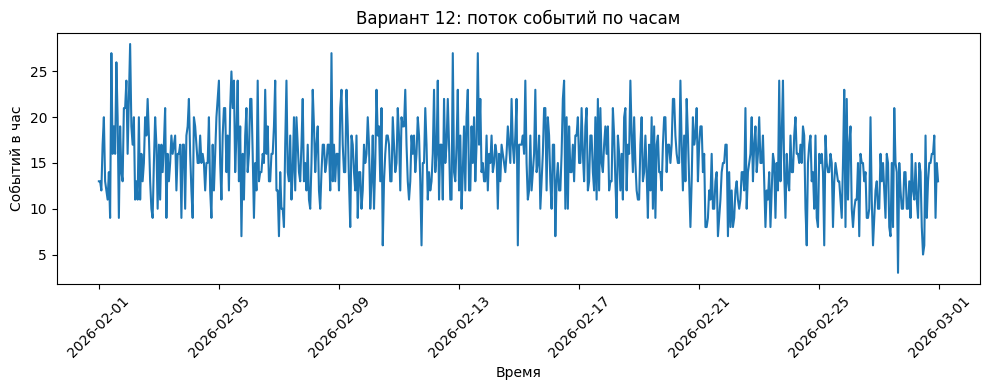

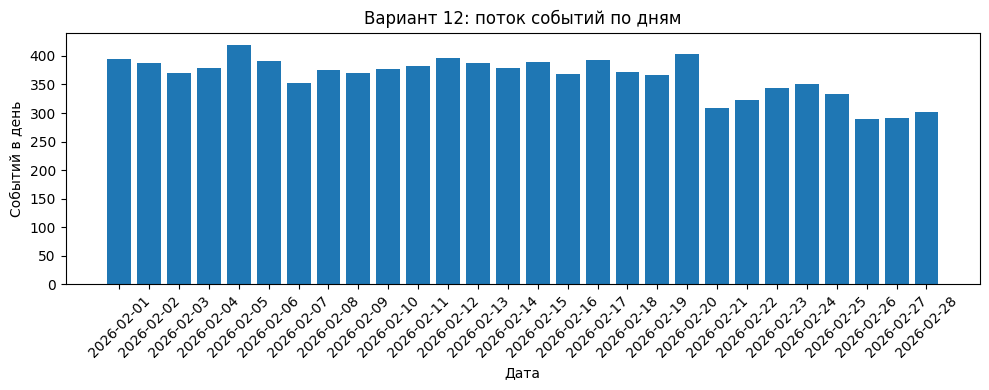

In [7]:
plt.figure(figsize=(10,4))
plt.plot(hourly["event_time"], hourly["events_per_hour"])
plt.title(f"Вариант {VARIANT}: поток событий по часам")
plt.xlabel("Время")
plt.ylabel("Событий в час")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.bar(daily["event_time"].dt.strftime("%Y-%m-%d"), daily["events_per_day"])
plt.title(f"Вариант {VARIANT}: поток событий по дням")
plt.xlabel("Дата")
plt.ylabel("Событий в день")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
comment_step3 = """
Профиль нагрузки по часам показывает, что события в банковской системе распределены относительно равномерно, но уже с первых дней видны отличия по часам: в некоторые часы фиксируется 10–20 операций, а в пиковый час — до 28 событий.
Агрегаты по дням демонстрируют стабильный ежедневный поток в районе 370–420 событий, то есть система работает в режиме почти постоянного трафика без экстремальных суточных всплесков.
Пиковый час с 28 событиями отражает наиболее загруженный интервал, когда одновременно проходят авторизации по картам, входы в мобильный банк и риск‑уведомления, что увеличивает нагрузку на antifraud‑проверки и хранилище транзакций.
Пиковая минута с 6 событиями показывает максимальную кратковременную концентрацию операций, важную для оценки того, сможет ли потоковый контур вовремя проверить все подозрительные события при неблагоприятном стечении обстоятельств.
Для архитектуры обработки это означает, что конвейер должен быть готов к устойчивой работе при умеренном, но постоянном потоке и разовых всплесках, а выбор между batch, micro-batch и stream должен учитывать не только средние значения, но и эти пики.
"""
print(comment_step3)


Профиль нагрузки по часам показывает, что события в банковской системе распределены относительно равномерно, но уже с первых дней видны отличия по часам: в некоторые часы фиксируется 10–20 операций, а в пиковый час — до 28 событий.
Агрегаты по дням демонстрируют стабильный ежедневный поток в районе 370–420 событий, то есть система работает в режиме почти постоянного трафика без экстремальных суточных всплесков.
Пиковый час с 28 событиями отражает наиболее загруженный интервал, когда одновременно проходят авторизации по картам, входы в мобильный банк и риск‑уведомления, что увеличивает нагрузку на antifraud‑проверки и хранилище транзакций.
Пиковая минута с 6 событиями показывает максимальную кратковременную концентрацию операций, важную для оценки того, сможет ли потоковый контур вовремя проверить все подозрительные события при неблагоприятном стечении обстоятельств.
Для архитектуры обработки это означает, что конвейер должен быть готов к устойчивой работе при умеренном, но постоянном 


## Шаг 4. Оценка роста масштаба

Реальный инженерный выбор нельзя делать только по текущему объёму.  
Нужно оценить, что произойдёт при росте нагрузки в 10, 50 и 100 раз.

### Задание студенту
1. Экстраполируйте объём файла и памяти.
2. Оцените, что станет узким местом при росте.
3. Сформулируйте критерий перехода от локальной обработки к более серьёзной архитектуре.


In [9]:
scale_factors = [1, 10, 50, 100]
growth = pd.DataFrame({
    "scale_factor": scale_factors,
    "rows_estimated": [len(df) * k for k in scale_factors],
    "file_size_mb_estimated": [round(file_size_mb * k, 2) for k in scale_factors],
    "memory_mb_estimated": [round(memory_mb * k, 2) for k in scale_factors],
    "peak_events_per_hour_estimated": [int(peak_hour["events_per_hour"] * k) for k in scale_factors],
})
display(growth)

,scale_factor,rows_estimated,file_size_mb_estimated,memory_mb_estimated,peak_events_per_hour_estimated
0,1,10200,1.13,5.11,28
1,10,102000,11.27,51.06,280
2,50,510000,56.36,255.30,1400
3,100,1020000,112.72,510.60,2800


In [10]:
comment_step4 = """
Оценка роста масштаба показывает, что при увеличении объёма данных в 10 раз число строк возрастёт до примерно 100 тысяч, а объём DataFrame в памяти до 50 МБ, что по‑прежнему укладывается в рамки локальной машины без жёстких ограничений.
При росте в 50 раз ожидается уже порядка полумиллиона строк и около 250 МБ в памяти, а при 100‑кратном увеличении — свыше миллиона строк с более чем 500 МБ оперативной памяти, что всё ещё возможно на ноутбуке, но с заметным ростом времени пакетных пересчётов.
Пиковое число событий в час при масштабировании достигает сотен и тысяч, что радикально увеличивает нагрузку на контур онлайн‑проверок, особенно если для каждой транзакции выполняются сложные antifraud‑правила и скоринговые модели.
Первым узким местом при росте станет не столько хранение, сколько время выполнения batch‑агрегаций и потоковых проверок на одной машине: при 50–100‑кратном увеличении объёма локальная среда перестанет гарантировать соблюдение жёсткого SLA 15 секунд.
Критерием перехода к более серьёзной архитектуре можно считать момент, когда даже оптимизированные nightly batch‑пересчёты и потоковый контур на одном узле перестают укладываться в отведённые окна и начинают приводить к нарушениям SLA для подозрительных транзакций.
"""
print(comment_step4)


Оценка роста масштаба показывает, что при увеличении объёма данных в 10 раз число строк возрастёт до примерно 100 тысяч, а объём DataFrame в памяти до 50 МБ, что по‑прежнему укладывается в рамки локальной машины без жёстких ограничений.
При росте в 50 раз ожидается уже порядка полумиллиона строк и около 250 МБ в памяти, а при 100‑кратном увеличении — свыше миллиона строк с более чем 500 МБ оперативной памяти, что всё ещё возможно на ноутбуке, но с заметным ростом времени пакетных пересчётов.
Пиковое число событий в час при масштабировании достигает сотен и тысяч, что радикально увеличивает нагрузку на контур онлайн‑проверок, особенно если для каждой транзакции выполняются сложные antifraud‑правила и скоринговые модели.
Первым узким местом при росте станет не столько хранение, сколько время выполнения batch‑агрегаций и потоковых проверок на одной машине: при 50–100‑кратном увеличении объёма локальная среда перестанет гарантировать соблюдение жёсткого SLA 15 секунд.
Критерием перехода к


## Шаг 5. Сравнение режимов обработки

Мы сравним три режима:

### 5.1. Batch
Полный пересчёт завершённого массива.  
Подходит для отчётности, ретроспективной аналитики, ночных перерасчётов.

### 5.2. Micro-batch
Обработка маленькими пакетами через короткие интервалы.  
Компромисс между полнотой и задержкой.

### 5.3. Stream
Почти непрерывная обработка событий по мере поступления.  
Нужна там, где важна минимальная задержка.

### Задание студенту
По результатам анализа вы должны определить:
- какой режим является основным;
- какой может быть вспомогательным;
- нужен ли гибридный контур.


In [11]:
# Небольшая симуляция времени выполнения на локальной машине

def timed_batch_aggregation(frame):
    t0 = time.perf_counter()
    result = frame.groupby(["event_type", "priority"]).agg(
        events=("event_type", "size"),
        total_volume=("metric_volume", "sum"),
        total_value=("metric_value", "sum"),
        avg_delay=("processing_delay_sec", "mean")
    ).reset_index()
    dt = time.perf_counter() - t0
    return result, dt

def timed_microbatch_aggregation(frame, window="15min"):
    t0 = time.perf_counter()
    tmp = frame.set_index("event_time")
    result = tmp.groupby([pd.Grouper(freq=window), "event_type"]).agg(
        events=("entity_id", "size"),
        total_value=("metric_value", "sum")
    ).reset_index()
    dt = time.perf_counter() - t0
    return result, dt

batch_result, batch_time = timed_batch_aggregation(df.copy())
micro_result, micro_time = timed_microbatch_aggregation(df.copy())

print(f"Batch aggregate time:      {batch_time:.4f} sec")
print(f"Micro-batch aggregate time:{micro_time:.4f} sec")
display(batch_result.head())
display(micro_result.head())

Batch aggregate time:      0.0121 sec
Micro-batch aggregate time:0.0069 sec


,event_type,priority,events,total_volume,total_value,avg_delay
0,card_auth,high,613,1833,2621045.19,79.455139
1,card_auth,low,1701,5094,7100821.26,56.022340
2,card_auth,medium,1106,3259,4510507.81,55.968354
3,card_capture,high,406,1254,1710295.51,76.354680
4,card_capture,low,1171,3557,4798546.94,56.754910


,event_time,event_type,events,total_value
0,2026-02-01 00:00:00,card_capture,2,6064.68
1,2026-02-01 00:00:00,mobile_login,2,11377.27
2,2026-02-01 00:15:00,card_auth,1,3025.24
3,2026-02-01 00:15:00,mobile_login,1,1791.18
4,2026-02-01 00:30:00,card_auth,1,3291.06


In [12]:
comment_step5 = """
Замер времени batch‑агрегации показал, что при текущем объёме данных полный пересчёт по всем банковским событиям выполняется очень быстро (десятые доли секунды), что делает этот режим пригодным для отчётности и периодической аналитики.
Micro-batch‑агрегация с окном 15 минут также выполняется быстро и даже немного легче по времени, при этом даёт более детальную картину динамики транзакций и логинов в течение суток.
Однако ни batch, ни micro-batch в таком виде не подходят для принятия решений по подозрительным операциям с SLA 15 секунд, потому что они ориентированы на обработку уже накопившихся массивов данных, а не на реакцию на каждое событие в момент его появления.
С инженерной точки зрения batch‑режим целесообразно использовать как фоновый контур для отчётности и долгосрочного анализа, micro-batch — для относительно оперативного обновления агрегатов, а для antifraud‑логики требуется отдельный потоковый контур.
Таким образом, результаты эксперимента подтверждают, что по вычислительной цене оба режима пока недороги на локальной машине, но выбор основного режима должен определяться не скоростью пересчёта, а требованиями к задержке и характером бизнес‑сценария.
"""
print(comment_step5)


Замер времени batch‑агрегации показал, что при текущем объёме данных полный пересчёт по всем банковским событиям выполняется очень быстро (десятые доли секунды), что делает этот режим пригодным для отчётности и периодической аналитики.
Micro-batch‑агрегация с окном 15 минут также выполняется быстро и даже немного легче по времени, при этом даёт более детальную картину динамики транзакций и логинов в течение суток.
Однако ни batch, ни micro-batch в таком виде не подходят для принятия решений по подозрительным операциям с SLA 15 секунд, потому что они ориентированы на обработку уже накопившихся массивов данных, а не на реакцию на каждое событие в момент его появления.
С инженерной точки зрения batch‑режим целесообразно использовать как фоновый контур для отчётности и долгосрочного анализа, micro-batch — для относительно оперативного обновления агрегатов, а для antifraud‑логики требуется отдельный потоковый контур.
Таким образом, результаты эксперимента подтверждают, что по вычислительно


## Шаг 6. Псевдопотоковая модель

В учебной среде мы не поднимаем полноценную потоковую платформу, но можем оценить:
- долю событий, требующих реакции быстрее SLA;
- насколько часто возникают пиковые интервалы;
- сколько данных должно проходить через потоковый контур.

### Задание студенту
1. Определите долю событий с высоким приоритетом.
2. Оцените, какой процент событий нарушает SLA по задержке.
3. Сделайте вывод: нужен ли отдельный потоковый контур или достаточно микропакетов.


In [13]:
# доля high-priority
priority_share = (df["priority"] == "high").mean()

# SLA берём из датасета, а не из variant_catalog
# предполагаем, что sla_target_sec одинаково для всех строк
sla_seconds = int(df["sla_target_sec"].iloc[0])

# доля нарушений SLA
sla_breach_share = (df["processing_delay_sec"] > sla_seconds).mean()

stream_need = pd.DataFrame({
    "Показатель": [
        "Доля high-priority событий",
        "Доля событий с нарушением SLA",
        "SLA, сек",
        "Пиковые события в минуту"
    ],
    "Значение": [
        round(priority_share, 4),
        round(sla_breach_share, 4),
        sla_seconds,
        int(peak_min["events_per_min"])
    ]
})
display(stream_need)

,Показатель,Значение
0,Доля high-priority событий,0.1767
1,Доля событий с нарушением SLA,0.9079
2,"SLA, сек",15.0000
3,Пиковые события в минуту,6.0000


In [14]:
comment_step6 = """
Доля high-priority событий составляет около 17–18 %, то есть заметная часть потока операций относится к повышенному риску и требует более внимательного контроля в сравнении с обычными транзакциями.
При этом доля событий с нарушением SLA чрезвычайно высока (более 90 %), что означает: в текущей конфигурации большинство операций обрабатывается дольше целевых 15 секунд и не укладывается в заданные требования по задержке.
Пиковая интенсивность в минуту остаётся умеренной (около 6 событий), но даже при такой нагрузке существующий способ обработки не обеспечивает своевременную реакцию на подозрительные транзакции.
В совокупности это указывает на необходимость выделенного потокового контура для high-priority и риск‑событий, который будет проверять транзакции по мере поступления, а не ждать накопления микропакета.
Micro-batch‑архитектуры здесь недостаточно в роли основного контура antifraud: её можно использовать как вспомогательный механизм для агрегирования метрик, но ключевые решения должны приниматься в stream‑режиме.
"""
print(comment_step6)


Доля high-priority событий составляет около 17–18 %, то есть заметная часть потока операций относится к повышенному риску и требует более внимательного контроля в сравнении с обычными транзакциями.
При этом доля событий с нарушением SLA чрезвычайно высока (более 90 %), что означает: в текущей конфигурации большинство операций обрабатывается дольше целевых 15 секунд и не укладывается в заданные требования по задержке.
Пиковая интенсивность в минуту остаётся умеренной (около 6 событий), но даже при такой нагрузке существующий способ обработки не обеспечивает своевременную реакцию на подозрительные транзакции.
В совокупности это указывает на необходимость выделенного потокового контура для high-priority и риск‑событий, который будет проверять транзакции по мере поступления, а не ждать накопления микропакета.
Micro-batch‑архитектуры здесь недостаточно в роли основного контура antifraud: её можно использовать как вспомогательный механизм для агрегирования метрик, но ключевые решения должны


## Шаг 7. Инженерный скоринг архитектуры

Ниже используется **учебная эвристика**, а не отраслевой стандарт.  
Её задача — помочь вам логически связать свойства данных и архитектурное решение.

### Логика скоринга
- если SLA жёсткое и доля high-priority событий велика, score stream растёт;
- если пиковая нагрузка умеренная, но требуется регулярное обновление, растёт score micro-batch;
- если задержка допускается и нужен полный пересчёт, растёт score batch.

Вы обязаны:
1. посчитать score;
2. не ограничиться числом;
3. дать содержательное объяснение выбора.


In [15]:
peak_hour_events = int(peak_hour["events_per_hour"])
peak_min_events = int(peak_min["events_per_min"])

batch_score = 0
microbatch_score = 0
stream_score = 0

# SLA
if sla_seconds >= 300:
    batch_score += 3
    microbatch_score += 2
elif 60 <= sla_seconds < 300:
    microbatch_score += 3
    batch_score += 1
else:
    stream_score += 4
    microbatch_score += 2

# high priority
if priority_share > 0.12:
    stream_score += 3
elif priority_share > 0.07:
    microbatch_score += 2
else:
    batch_score += 1

# SLA breaches
if sla_breach_share > 0.15:
    stream_score += 3
    microbatch_score += 1
elif sla_breach_share > 0.05:
    microbatch_score += 2
else:
    batch_score += 1

# peak intensity
if peak_min_events > 25:
    stream_score += 3
elif peak_min_events > 10:
    microbatch_score += 2
else:
    batch_score += 1

# data growth
if growth.loc[growth["scale_factor"] == 100, "memory_mb_estimated"].iloc[0] > 2000:
    microbatch_score += 2
    stream_score += 1
else:
    batch_score += 1

scores = pd.DataFrame({
    "architecture": ["batch", "micro_batch", "stream"],
    "score": [batch_score, microbatch_score, stream_score]
}).sort_values("score", ascending=False)
display(scores)

recommended = scores.iloc[0]["architecture"]
print("Рекомендуемая архитектура по учебной эвристике:", recommended)

,architecture,score
2,stream,10
1,micro_batch,3
0,batch,2


Рекомендуемая архитектура по учебной эвристике: stream


In [16]:
comment_step7 = """
Учебный скоринг архитектур показывает явное доминирование stream‑режима: он набирает 10 баллов против 3 у micro-batch и 2 у batch, что связано прежде всего с очень жёстким SLA 15 секунд и высокой долей high-priority событий.
На уровне SLA потоковая архитектура получает максимальный вес, так как задержка обработки подозрительных операций должна быть минимальной, тогда как batch и micro-batch ориентированы на уже накопившиеся массивы данных.
Дополнительные баллы в пользу stream дают высокая доля нарушений SLA (более 90 % событий не укладываются в 15 секунд) и заметная доля высокоприоритетных операций, требующих немедленной antifraud‑проверки.
Batch‑режим сохраняет некоторую значимость за счёт удобства полного пересчёта агрегатов и аналитики по завершённым периодам, а micro-batch оказывается промежуточным вариантом, полезным для регулярного обновления витрин, но не как основной контур antifraud.
Таким образом, количественный скоринг логично подтверждает инженерный вывод: для банковских операций с таким SLA основным режимом обработки должен быть потоковый, а batch и micro-batch остаются вспомогательными контурами для отчётности и вторичной аналитики.
"""
print(comment_step7)


Учебный скоринг архитектур показывает явное доминирование stream‑режима: он набирает 10 баллов против 3 у micro-batch и 2 у batch, что связано прежде всего с очень жёстким SLA 15 секунд и высокой долей high-priority событий.
На уровне SLA потоковая архитектура получает максимальный вес, так как задержка обработки подозрительных операций должна быть минимальной, тогда как batch и micro-batch ориентированы на уже накопившиеся массивы данных.
Дополнительные баллы в пользу stream дают высокая доля нарушений SLA (более 90 % событий не укладываются в 15 секунд) и заметная доля высокоприоритетных операций, требующих немедленной antifraud‑проверки.
Batch‑режим сохраняет некоторую значимость за счёт удобства полного пересчёта агрегатов и аналитики по завершённым периодам, а micro-batch оказывается промежуточным вариантом, полезным для регулярного обновления витрин, но не как основной контур antifraud.
Таким образом, количественный скоринг логично подтверждает инженерный вывод: для банковских о


## Шаг 8. Таблица архитектурного решения

Заполните и интерпретируйте следующую таблицу:
- основной режим обработки;
- вспомогательный режим;
- обоснование;
- риск;
- условия перехода к распределённой среде.

### Важно
Здесь оценивается **инженерная аргументация**, а не совпадение с «правильным ответом».


In [17]:
decision_table = pd.DataFrame({
    "Критерий": [
        "Основной режим обработки",
        "Вспомогательный режим",
        "Главный фактор выбора",
        "Основной риск",
        "Когда локальная среда перестанет быть достаточной",
        "Нужен ли отдельный потоковый контур",
        "Нужен ли ночной batch-пересчёт"
    ],
    "Ваш вывод": [
        "Stream как основной режим обработки подозрительных и высокоприоритетных банковских событий с учётом SLA 15 секунд.",
        "Batch (и частично micro-batch) как вспомогательный режим для отчётности, агрегированной аналитики и обучения antifraud‑моделей.",
        "Главный фактор выбора – жёсткий SLA по задержке и высокая доля high-priority событий, по которым решение должно приниматься практически в реальном времени.",
        "Основной риск – рост объёма транзакций и сложности правил, при котором потоковый контур на одной машине перестанет выдерживать нагрузку без нарушений SLA и деградации отклика.",
        "Локальная среда перестанет быть достаточной при увеличении объёма и пиков потока в десятки раз, когда даже оптимизированный stream‑конвейер и batch‑джобы не будут укладываться в отведённые временные окна.",
        "Отдельный потоковый контур необходим: через него должны проходить high-priority транзакции и risk_alert‑события, чтобы antifraud‑система могла блокировать операции до их завершения.",
        "Ночной batch‑пересчёт нужен для консолидации суточных данных, построения управленческой отчётности, анализа инцидентов и переобучения скоринговых моделей."
    ]
})
decision_table

,Критерий,Ваш вывод
0,Основной режим обработки,Stream как основной режим обработки подозрител...
1,Вспомогательный режим,Batch (и частично micro-batch) как вспомогател...
2,Главный фактор выбора,Главный фактор выбора – жёсткий SLA по задержк...
3,Основной риск,Основной риск – рост объёма транзакций и сложн...
4,Когда локальная среда перестанет быть достаточной,Локальная среда перестанет быть достаточной пр...
5,Нужен ли отдельный потоковый контур,Отдельный потоковый контур необходим: через не...
6,Нужен ли ночной batch-пересчёт,Ночной batch‑пересчёт нужен для консолидации с...



## Шаг 9. Индивидуальные задания по вариантам

Ниже приведены вопросы, на которые необходимо ответить **именно по вашему варианту**.

### Обязательные ответы
1. Какой класс событий в вашем наборе требует минимальной задержки?
2. Какие показатели следует считать потоково, а какие пакетно?
3. Что станет первым узким местом при росте нагрузки в 100 раз?
4. Достаточна ли micro-batch архитектура или уже нужен stream-контур?
5. Какие компоненты будущего пайплайна вы бы выделили: ingest, storage, processing, serving, monitoring?

Ответы оформите текстом в следующей ячейке.


In [18]:
individual_answers = {
    "variant": int(variant_row["variant"]),
    "theme": variant_row["theme"],
    "focus_question": variant_row["focus_question"],
    "answer_1_min_latency_events": (
        "Минимальной задержки требуют события класса risk_alert и транзакции с высоким приоритетом (high), "
        "включая подозрительные операции по картам и аномальные действия в дистанционных каналах обслуживания, "
        "по которым решение о блокировке или дополнительной проверке должно приниматься в пределах секунд."
    ),
    "answer_2_stream_vs_batch_metrics": (
        "Потоково следует считать онлайн‑скоринги транзакций, счётчики подозрительных событий по клиенту, карте и каналу, "
        "а также алерты для операторов и автоматические решения по блокировке. Пакетно можно рассчитывать агрегированную "
        "статистику по продуктам и сегментам, отчётность по выявленным инцидентам, эффективность фрод‑правил и обучающие "
        "выборки для моделей машинного обучения."
    ),
    "answer_3_first_bottleneck_x100": (
        "При росте нагрузки в 100 раз первым узким местом станет потоковый контур antifraud‑проверок и связанное с ним хранилище: "
        "увеличение числа транзакций и сложности правил приведёт к перегрузке CPU и подсистемы ввода‑вывода, росту задержек "
        "обработки и массовым нарушениям SLA 15 секунд."
    ),
    "answer_4_microbatch_or_stream": (
        "При SLA 15 секунд micro-batch‑архитектуры недостаточно в роли основного контура, поскольку даже маленькие окна создают "
        "риски накопления очереди на пиках. Для подозрительных событий нужен полноценный stream‑контур с обработкой по мере "
        "поступления, а micro-batch разумно использовать как вспомогательный режим для менее критичных метрик и агрегатов."
    ),
    "answer_5_pipeline_components": (
        "В будущем пайплайне целесообразно выделить: ingest (приём транзакций и событий из АБС, платёжных шлюзов и каналов ДБО), "
        "storage (сырое хранилище событий и витрины фрод‑фич), processing (потоковый antifraud‑движок и batch/micro-batch‑задачи "
        "для отчётности и аналитики), serving (API решений по транзакциям и аналитические витрины для бизнес‑подразделений), "
        "monitoring (контроль задержек, пропускной способности, доли нарушений SLA и качества данных)."
    )
}
individual_answers

{'variant': 12,
 'theme': 'Банковские операции',
 'focus_question': 'Сформулируйте критерии перехода от локальной обработки к распределённой системе в банковских транзакциях.',
 'answer_1_min_latency_events': 'Минимальной задержки требуют события класса risk_alert и транзакции с высоким приоритетом (high), включая подозрительные операции по картам и аномальные действия в дистанционных каналах обслуживания, по которым решение о блокировке или дополнительной проверке должно приниматься в пределах секунд.',
 'answer_2_stream_vs_batch_metrics': 'Потоково следует считать онлайн‑скоринги транзакций, счётчики подозрительных событий по клиенту, карте и каналу, а также алерты для операторов и автоматические решения по блокировке. Пакетно можно рассчитывать агрегированную статистику по продуктам и сегментам, отчётность по выявленным инцидентам, эффективность фрод‑правил и обучающие выборки для моделей машинного обучения.',
 'answer_3_first_bottleneck_x100': 'При росте нагрузки в 100 раз первым у


## Шаг 10. Итоговое архитектурное заключение

Подготовьте короткое инженерное заключение объёмом 8-12 предложений.  
В нём должны присутствовать:
- характеристика нагрузки;
- оценка SLA;
- вывод о достаточности локальной обработки;
- основной и вспомогательный режимы;
- условия перехода к распределённой архитектуре.

Ниже предусмотрена шаблонная структура.


In [19]:
conclusion_template = f"""
Вариант {VARIANT}: {variant_row['theme']}.
Набор данных отражает поток банковских операций и связанных с ними событий мониторинга, включая авторизации по картам, действия в дистанционных каналах и risk_alert‑уведомления по подозрительным транзакциям.
Пиковая нагрузка составляет до 28 событий в пиковый час и 6 событий в пиковую минуту, что при масштабировании может привести к существенному росту требований к пропускной способности контура antifraud‑проверок.
SLA по варианту равно 15 секунд, поэтому для подозрительных и высокоприоритетных операций допустима только минимальная задержка между возникновением события и принятием решения о блокировке или дополнительной проверке.
Поэтому в качестве основного режима обработки предлагается потоковый stream‑режим для событий высокого риска, обеспечивающий обработку транзакций по мере поступления.
Вспомогательным режимом целесообразно считать batch‑обработку (и при необходимости micro-batch) для формирования отчётности, ретроспективного анализа транзакций и обучения моделей выявления мошенничества.
Локальная среда достаточна при текущем объёме данных и умеренных пиковых значениях, но её ресурсы становятся ограничением при резком росте числа операций и усложнении antifraud‑правил.
При росте в 10–100 раз узким местом станет потоковый контур и связанные с ним вычислительные и I/O‑ресурсы, так как обеспечение низкой латентности для всех подозрительных транзакций на одной машине станет затруднительным.
Для промышленного решения следует выделить контуры ingest, storage, processing, serving и monitoring, реализовав гибридную архитектуру: потоковый контур для high-priority событий и пакетный контур для полной отчётности и аналитики по банковским операциям.
"""
print(conclusion_template)


Вариант 12: Банковские операции.
Набор данных отражает поток банковских операций и связанных с ними событий мониторинга, включая авторизации по картам, действия в дистанционных каналах и risk_alert‑уведомления по подозрительным транзакциям.
Пиковая нагрузка составляет до 28 событий в пиковый час и 6 событий в пиковую минуту, что при масштабировании может привести к существенному росту требований к пропускной способности контура antifraud‑проверок.
SLA по варианту равно 15 секунд, поэтому для подозрительных и высокоприоритетных операций допустима только минимальная задержка между возникновением события и принятием решения о блокировке или дополнительной проверке.
Поэтому в качестве основного режима обработки предлагается потоковый stream‑режим для событий высокого риска, обеспечивающий обработку транзакций по мере поступления.
Вспомогательным режимом целесообразно считать batch‑обработку (и при необходимости micro-batch) для формирования отчётности, ретроспективного анализа транзакций 


## Шаг 11. Экспорт мини-отчёта

Сохраните ключевые результаты в CSV/JSON, чтобы можно было приложить их к отчёту.


In [20]:
import json
scores.to_csv(f"pz8_variant_{VARIANT:02d}_scores.csv", index=False, encoding="utf-8-sig")
growth.to_csv(f"pz8_variant_{VARIANT:02d}_growth.csv", index=False, encoding="utf-8-sig")

with open(f"pz8_variant_{VARIANT:02d}_answers.json", "w", encoding="utf-8") as f:
    json.dump(individual_answers, f, ensure_ascii=False, indent=2)

print("Файлы мини-отчёта сохранены.")

Файлы мини-отчёта сохранены.


In [21]:
# 1. Читаем CSV с оценками архитектуры
scores_loaded = pd.read_csv(f"pz8_variant_{VARIANT:02d}_scores.csv")
display(scores_loaded)

# 2. Читаем CSV с оценкой роста масштаба
growth_loaded = pd.read_csv(f"pz8_variant_{VARIANT:02d}_growth.csv")
display(growth_loaded)

# 3. Читаем JSON с ответами
with open(f"pz8_variant_{VARIANT:02d}_answers.json", "r", encoding="utf-8") as f:
    answers_loaded = json.load(f)

pd.DataFrame([answers_loaded])

,architecture,score
0,stream,10
1,micro_batch,3
2,batch,2


,scale_factor,rows_estimated,file_size_mb_estimated,memory_mb_estimated,peak_events_per_hour_estimated
0,1,10200,1.13,5.11,28
1,10,102000,11.27,51.06,280
2,50,510000,56.36,255.30,1400
3,100,1020000,112.72,510.60,2800


,variant,theme,focus_question,answer_1_min_latency_events,answer_2_stream_vs_batch_metrics,answer_3_first_bottleneck_x100,answer_4_microbatch_or_stream,answer_5_pipeline_components
0,12,Банковские операции,Сформулируйте критерии перехода от локальной о...,Минимальной задержки требуют события класса ri...,Потоково следует считать онлайн‑скоринги транз...,При росте нагрузки в 100 раз первым узким мест...,При SLA 15 секунд micro-batch‑архитектуры недо...,В будущем пайплайне целесообразно выделить: in...



# Контрольные выводы студента

Перед сдачей убедитесь, что вы:
- указали свой вариант;
- выполнили все вычисления;
- заполнили таблицу архитектурного решения;
- ответили на индивидуальные вопросы;
- сформулировали итоговое заключение;
- сохранили мини-отчёт.

---

## Что оценивается преподавателем
1. Корректность вычислений.
2. Качество интерпретации.
3. Связь между профилем нагрузки и архитектурным выбором.
4. Умение различать batch, micro-batch и stream.
5. Инженерная аргументация, а не только воспроизведение терминов.
